<a href="https://colab.research.google.com/github/AbhishekShah272002/Deep-Learning-and-NLP/blob/main/Air_Traffic_Movements_Using_RNN_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install tensorflow

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [17]:
df = pd.read_csv("AirTrafficMovements.csv")
df.head()

,Year,Month,Aircraft_Arrival,Aircraft_Departure,Aircraft_Total,Passenger_Arrival,Passenger_Departures,Passenger_Transit,Passenger_Total,AirMail_Incoming,AirMail_Outgoing,AirMail_Total,Cargo_Total_Import,Cargo_Total_Export,Cargo_Total
0,2015,2015-01,"14,384","14,396","28,780","2,243,305","2,112,813","64,004","4,420,122","1,193.62","1,614.88","2,808.50","81,867.90","69,946.38","151,814.28"
1,2015,2015-02,"13,249","13,242","26,491","2,018,729","2,056,989","45,639","4,121,357",974.9702,"1,277.43","2,252.40","75,576.73","60,388.68","135,965.42"
2,2015,2015-03,"14,390","14,403","28,793","2,237,167","2,245,963","51,989","4,535,119","1,112.62","1,485.10","2,597.72","89,020.39","73,639.48","162,659.86"
3,2015,2015-04,"14,126","14,130","28,256","2,181,441","2,151,585","58,355","4,391,381","1,095.82","1,391.80","2,487.62","83,906.47","69,541.16","153,447.64"
4,2015,2015-05,"14,519","14,523","29,042","2,177,764","2,250,744","51,753","4,480,261","1,183.51","1,523.83","2,707.34","86,950.64","70,095.57","157,046.21"


In [18]:
df.shape

(138, 15)

In [19]:
print("\nMissing Values")
df.isnull().sum()


Missing Values


,0
Year,0
Month,0
Aircraft_Arrival,0
Aircraft_Departure,0
Aircraft_Total,0
Passenger_Arrival,0
Passenger_Departures,0
Passenger_Transit,0
Passenger_Total,0
AirMail_Incoming,0


In [20]:
df.describe()

,Year
count,138.000000
mean,2020.260870
std,3.338133
min,2015.000000
25%,2017.000000
50%,2020.000000
75%,2023.000000
max,2026.000000


### Select Passenger total for RNN Predication

In [21]:
data = df[['Month', 'Passenger_Total']].copy()

data.head()

,Month,Passenger_Total
0,2015-01,"4,420,122"
1,2015-02,"4,121,357"
2,2015-03,"4,535,119"
3,2015-04,"4,391,381"
4,2015-05,"4,480,261"


### Convert Passenger_Total into Numeric Format

In [22]:
data['Passenger_Total'] = data['Passenger_Total'].astype(str).str.replace(',', '').astype(float)

data.head()

,Month,Passenger_Total
0,2015-01,4420122.0
1,2015-02,4121357.0
2,2015-03,4535119.0
3,2015-04,4391381.0
4,2015-05,4480261.0


### Convert Month to Data Format and Sort the Data

In [23]:
data['Month'] = pd.to_datetime(data['Month'])

data = data.sort_values('Month')

data.head()

,Month,Passenger_Total
0,2015-01-01,4420122.0
1,2015-02-01,4121357.0
2,2015-03-01,4535119.0
3,2015-04-01,4391381.0
4,2015-05-01,4480261.0


### Visualize the Passenger Time Series

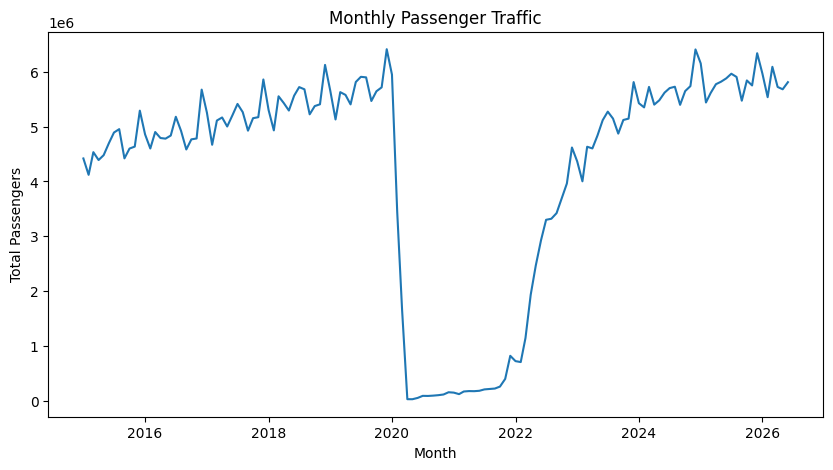

In [24]:
plt.figure(figsize=(10,5))

plt.plot(data['Month'], data['Passenger_Total'])

plt.xlabel('Month')
plt.ylabel('Total Passengers')
plt.title('Monthly Passenger Traffic')

plt.show()

### Scale the Passenger Data

In [25]:
scaler = MinMaxScaler(feature_range=(0,1))

passenger_data = data[['Passenger_Total']].values

scaled_data = scaler.fit_transform(passenger_data)

print(scaled_data[:5])

[[0.68789111]
 [0.64113596]
 [0.70588754]
 [0.68339329]
 [0.69730255]]


### Create Sequences for the RNN


In [27]:
x = []
y = []

time_steps = 12

for i in range(time_steps, len(scaled_data)):
  x.append(scaled_data[i-time_steps:i, 0])
  y.append(scaled_data[i, 0])

x = np.array(x)
y = np.array(y)

print("x Shape:", x.shape)
print("y Shape:", y.shape)

x Shape: (126, 12)
y Shape: (126,)
